In [4]:
import xgboost as xgb
import numpy as np
import torch
from vbf_tagger.tools.data.flatpair_dataloader import FlatPairDataModule
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import mplhep as hep
from hydra import compose, initialize

In [5]:
with initialize(version_base=None, config_path="../config", job_name="visualize"):
    cfg = compose(config_name="main")

In [6]:
dm = FlatPairDataModule(cfg)
dm.setup(stage="fit")
dm.setup(stage="test")  # if you added test support

X_train = dm.train_dataset.tensors[0].numpy()
y_train = dm.train_dataset.tensors[1].numpy()

X_test = dm.test_dataset.tensors[0].numpy()
y_test = dm.test_dataset.tensors[1].numpy()

 Found 14 train files, 14 val files
 Class balance (train): 110329 positives, 1736268 negatives → pos_weight=15.74
 Found 14 test files


In [8]:
# Load model
bst = xgb.Booster()
bst.load_model("/home/norman/vbf-tagger/xgboost_vbf.json")

# Make predictions
dtrain = xgb.DMatrix(X_train)
dtest  = xgb.DMatrix(X_test)

pred_train = bst.predict(dtrain)
pred_test  = bst.predict(dtest)


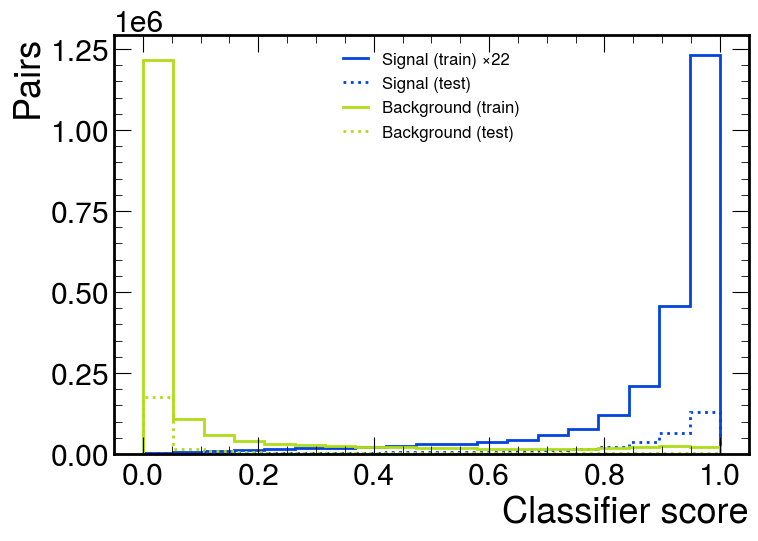

In [16]:
plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(8,6))

bins = np.linspace(0, 1, 20)
signal_scale = 22

# Signal train
hist, edges = np.histogram(pred_train[y_train==1], bins=bins)
hep.histplot((hist*signal_scale, edges),
             histtype='step', color='#0343df',
             label=f'Signal (train) ×{signal_scale}', linewidth=2)

# Signal test
hist, edges = np.histogram(pred_test[y_test==1], bins=bins)
hep.histplot((hist*signal_scale, edges),
             histtype='step', linestyle=':',
             color='#0343df', label='Signal (test)', linewidth=2)

# Background train
hep.histplot(np.histogram(pred_train[y_train==0], bins=bins),
             histtype='step', color='#b0dd16',
             label='Background (train)', linewidth=2)

# Background test
hep.histplot(np.histogram(pred_test[y_test==0], bins=bins),
             histtype='step', linestyle=':',
             color='#b0dd16', label='Background (test)', linewidth=2)

ax.set_xlabel("Classifier score")
ax.set_ylabel("Pairs")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


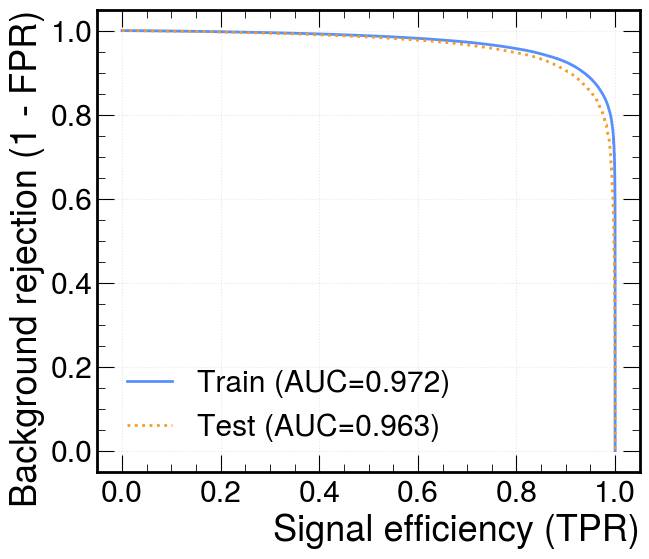

In [17]:
from sklearn.metrics import roc_curve, auc

# Train ROC
fpr_train, tpr_train, _ = roc_curve(y_train, pred_train)
roc_train = auc(fpr_train, tpr_train)

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test, pred_test)
roc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(7,6))
plt.plot(tpr_train, 1 - fpr_train, label=f"Train (AUC={roc_train:.3f})", linewidth=2)
plt.plot(tpr_test,  1 - fpr_test,  label=f"Test (AUC={roc_test:.3f})", linestyle=":", linewidth=2)

plt.xlabel("Signal efficiency (TPR)")
plt.ylabel("Background rejection (1 - FPR)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
